# Project Python for Data Science: Austo Automobiles

### Context

Austo Motor Company is a leading car manufacturer specializing in SUV, Sedan, and Hatchback models. In its recent board meeting, concerns were raised by the members on the efficiency of the marketing campaign currently being used. The board decides to rope in an analytics professional to improve the existing campaign.

### Objective

They want to analyze the data to get a fair idea about the demand of customers which will help them in enhancing their customer experience. Suppose you are a Data Scientist at the company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

* Age: The age of the individual in years.

* Gender: The gender of the individual, categorized as male or female.

* Profession: The occupation or profession of the individual.

* Marital_status: The marital status of the individual, such as married &, single

* Education: The educational qualification of the individual Graduate and Post Graduate

* No_of_Dependents: The number of dependents (e.g., children, elderly parents) that the individual supports financially.

* Personal_loan: A binary variable indicating whether the individual has taken a personal loan "Yes" or "No"

* House_loan: A binary variable indicating whether the individual has taken a housing loan "Yes" or "No"

* Partner_working: A binary variable indicating whether the individual's partner is employed "Yes" or "No"

* Salary: The individual's salary or income.

* Partner_salary: The salary or income of the individual's partner, if applicable.

* Total_salary: The total combined salary of the individual and their partner (if applicable).

* Price: The price of a product or service.

* Make: The type of automobile

### Let us start by importing the required libraries

In [48]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [49]:
df = pd.read_csv('data/austo_automobile.csv')
df.head()


In [51]:
# Returns the last 5 rows
df.tail()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
1576,22,Male,Salaried,Single,Graduate,2,No,Yes,No,33300,0.0,33300,27000,Hatchback
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback
1578,22,Male,Business,Single,Graduate,2,No,Yes,No,32900,0.0,32900,30000,Hatchback
1579,22,Male,Business,Married,Graduate,3,Yes,Yes,No,32200,NaN,32200,24000,Hatchback
1580,22,Male,Salaried,Married,Graduate,4,No,No,No,31600,0.0,31600,31000,Hatchback


### How many rows and columns are present in the data?

In [52]:
# Check the shape of the dataset
df.shape

(1581, 14)

###  What are the datatypes of the different columns in the dataset?

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


### Are there any missing values in the data? If yes, treat them using an appropriate method.

In [54]:
# Checking for missing values in the data
df.isnull().sum()

,0
Age,0
Gender,53
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


* The Gender column contains 1528 non-null values out of 1581 total entries.This indicates 53 missing values in the Gender column.

* The Partner_salary column contains 1475 non-null values.This means there are 106 missing entries in the Partner_salary column, possibly due to the partner not working or data not being reported.

In [55]:
df['Gender'].value_counts()

,count
Gender,
Male,1199
Female,327
Femal,1
Femle,1


In [56]:
df['Gender'] = df['Gender'].replace({'Femal': 'Female', 'Femle': 'Female'})
df['Gender'].value_counts()

,count
Gender,
Male,1199
Female,329


In [57]:
df['Gender'].describe()

,Gender
count,1528
unique,2
top,Male
freq,1199


* There are 53 missing values in the Gender column out of 1581 total rows, which accounts for approximately 3.4% of the dataset.

* Instead of dropping these rows, it's better to retain them by filling the missing values using the mode (most frequent gender), especially since the dataset is not very large.

* Gender is likely an important feature that could influence loan approval, salary, or product purchasing behavior, so preserving these rows can be beneficial for analysis.

* Imputing with the mode is a common and reasonable approach in this case, as it reflects the most likely value based on existing data.

* The most frequent gender is **Male**, which appears 980 times, indicating a male-dominant distribution in the dataset


In [58]:
#Fill missing Gender with the most frequent Gender, using mode
print(df['Gender'].mode())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Gender'].isnull().sum()


0    Male
Name: Gender, dtype: object


np.int64(0)

* Partner_salary had 106 missing values out of 1581 (≈6.7%).

* Likely missing where the partner is not working.

* Untreated, this could distort salary-related analysis and model performance.

In [59]:
# Set Partner Salary to 0 when the partner is not working
mask = (df['Partner_salary'].isnull()) & (df['Partner_working'] == 'No')

df.loc[mask, 'Partner_salary'] = 0

# Fill remaining missing Partner Salary values with the mean
remaining_missing = df['Partner_salary'].isnull()

df.loc[remaining_missing, 'Partner_salary'] = df['Partner_salary'].mean()

df['Partner_salary'].isnull().sum()

np.int64(0)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1581 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1581 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


* The Gender column had 53 missing values, which were filled using the mode ('Male'). This helps retain all records while preserving the most frequent category in the dataset.

* The Partner_salary column had 106 missing values.

  * First, missing values for individuals whose partner is not working were logically filled with 0.

  * Remaining missing values (where the partner is working but salary was missing) were filled using the mean of the column to maintain data continuity and reduce distortion.

### Check the statistical summary of the data. What are the minimum, average, and maximum values of Individuals' age,   Individuals' salary, Partner salary, Total salary and Product price?

In [61]:
# Get the summary statistics of the numerical data
df.describe()

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
count,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000
mean,31.922201,2.457938,60392.220114,19062.428115,79625.996205,35597.722960
std,8.425978,0.943483,14674.825044,19477.360938,25545.857768,13633.636545
min,22.000000,0.000000,30000.000000,0.000000,30000.000000,18000.000000
25%,25.000000,2.000000,51900.000000,0.000000,60500.000000,25000.000000
50%,29.000000,2.000000,59500.000000,24900.000000,78000.000000,31000.000000
75%,38.000000,3.000000,71800.000000,38000.000000,95900.000000,47000.000000
max,54.000000,4.000000,99300.000000,80500.000000,171000.000000,70000.000000


In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1581.0,19062.428115,19477.360938,0.0,0.0,24900.0,38000.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


* **Age:** Average age is 32, ranging from 22 to 54 years.

* **No. of Dependents:** Most individuals have 2–3 dependents, average is 2.46.

* **Salary:** Average salary is ₹60,392, with a wide range from ₹30,000 to ₹99,300.There is a considerable difference between the maximum value(₹99300) and 75th percentile(₹71800) of the data which indicated the presence of outliers.

* **Partner_salary:** Many partners don't work (25% earn ₹0), but the average is ₹19K with high variation values range from 0 (non-working partners) to ₹80,500, indicating potential outliers.

* **Total_salary:** Average combined income is ₹79,626, influenced by partner income, with values reaching up to ₹171,000, indicating potential outliers and the need for scaling in models.

* **Price:** Product prices average ₹35,598, with a range from ₹18,000 to ₹70,000 with possible outliers beyond ₹47,000.

* **Salary, Partner_salary, Total_salary, and Price show high value ranges with potential outliers that may require treatment.**

**Let's check the count and percentage of categorical levels in each column**

In [63]:
# Making a list of all categorical variables
cat_cols =  ['Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working','Make']

# Printing the count of unique categorical levels in each column
for column in cat_cols:
    print(df[column].value_counts())
    print("-" * 50)

Gender
Male      1252
Female     329
Name: count, dtype: int64
--------------------------------------------------
Profession
Salaried    896
Business    685
Name: count, dtype: int64
--------------------------------------------------
Marital_status
Married    1443
Single      138
Name: count, dtype: int64
--------------------------------------------------
Education
Post Graduate    985
Graduate         596
Name: count, dtype: int64
--------------------------------------------------
Personal_loan
Yes    792
No     789
Name: count, dtype: int64
--------------------------------------------------
House_loan
No     1054
Yes     527
Name: count, dtype: int64
--------------------------------------------------
Partner_working
Yes    868
No     713
Name: count, dtype: int64
--------------------------------------------------
Make
Sedan        702
Hatchback    582
SUV          297
Name: count, dtype: int64
--------------------------------------------------


In [64]:
 #Printing the percentage of unique categorical levels in each column
for column in cat_cols:
    print(df[column].value_counts(normalize=True))
    print("-" * 50)

Gender
Male      0.791904
Female    0.208096
Name: proportion, dtype: float64
--------------------------------------------------
Profession
Salaried    0.56673
Business    0.43327
Name: proportion, dtype: float64
--------------------------------------------------
Marital_status
Married    0.912713
Single     0.087287
Name: proportion, dtype: float64
--------------------------------------------------
Education
Post Graduate    0.623023
Graduate         0.376977
Name: proportion, dtype: float64
--------------------------------------------------
Personal_loan
Yes    0.500949
No     0.499051
Name: proportion, dtype: float64
--------------------------------------------------
House_loan
No     0.666667
Yes    0.333333
Name: proportion, dtype: float64
--------------------------------------------------
Partner_working
Yes    0.54902
No     0.45098
Name: proportion, dtype: float64
--------------------------------------------------
Make
Sedan        0.444023
Hatchback    0.368121
SUV          0.

* **Gender:**  Majority are Male (79%), with Female making up 21%.

* **Profession:** Salaried individuals (57%) slightly outnumber Business (43%).

* **Marital_status:** Most individuals are Married (91%), only 9% are Single.

* **Education:** Post Graduates form 62%, while Graduates are 38%.

* **Personal_loan:** Almost equally split — 51% Yes, 49% No.

* **House_loan:** Two-thirds (67%) do not have a house loan.

* **Partner_working:** 55% have working partners, 45% do not.

* **Make:** Sedans are most common (44%), followed by Hatchbacks (37%) and SUVs (19%).

### Univariate Analysis

**Observations on Age**

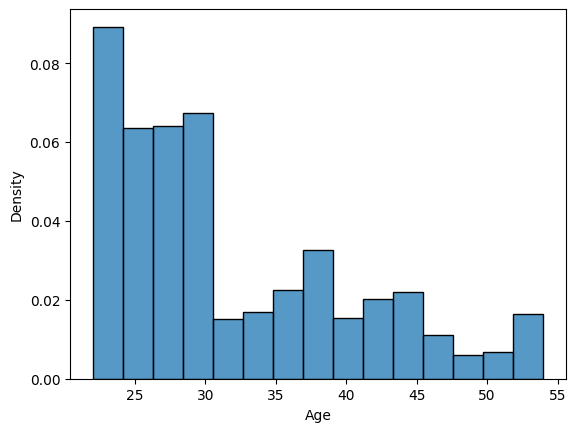

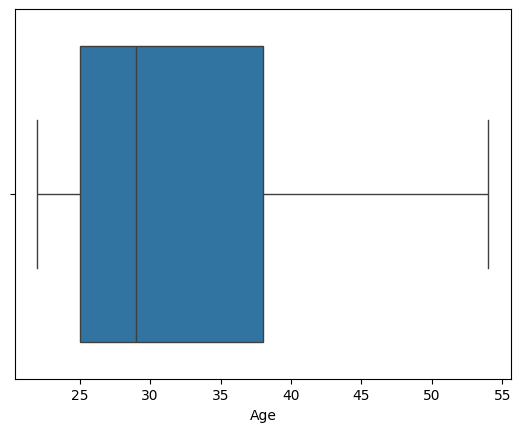

In [65]:
sns.histplot(data=df,x='Age',stat='density')
plt.show()
sns.boxplot(data=df,x='Age')
plt.show()

* The distribution of Age is right-skewed — i.e., most values are concentrated between the age 22 and 30.

* There are fewer observations in the 40+ age range.

* The peak density lies in the 25 to 30 age group.

**Observations on Gender**

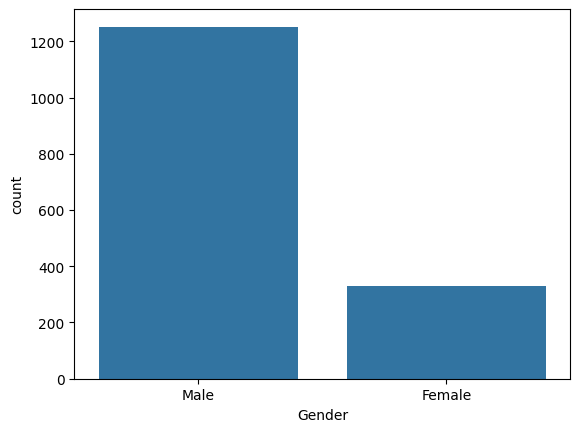

In [66]:
sns.countplot(data=df,x='Gender')
plt.show()

*  The dataset contains approximately 1,200 males and around 330 females, indicating that about 79% of the individuals are male, while only 21% are female.
* The number of males being nearly four times higher than that of females.

**Observations on Profession**

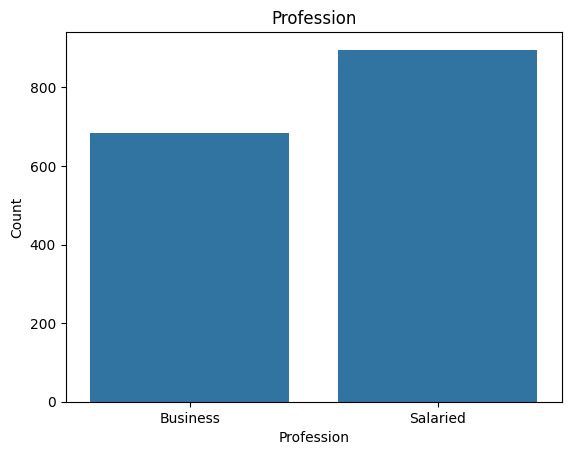

In [67]:
sns.countplot(data=df, x='Profession')
plt.title("Profession")
plt.xlabel("Profession")
plt.ylabel("Count")
plt.show()

* The plot shows that out of 1,581 individuals, approximately 890 are salaried and 690 are in business.
* This indicates that around 56.7% of the dataset consists of salaried professionals, while 43.3% are business professionals, highlighting a moderate difference in profession distribution.

**Observations on Salary**

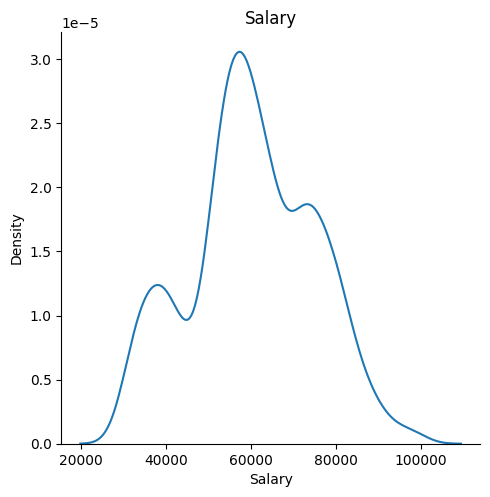

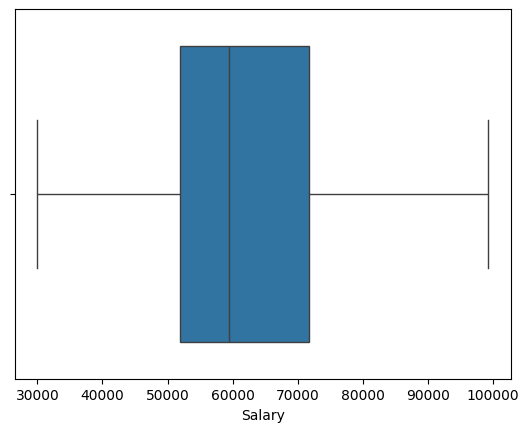

In [68]:
sns.displot(data=df,x='Salary',kind='kde')
plt.title("Salary")
plt.show()
sns.boxplot(data=df,x='Salary')
plt.show()

* The distribution plot for Salary shows that most individuals earn between ₹51,900 (25th percentile) and ₹71,800 (75th percentile), with a median salary of ₹59,500.
* The data ranges from a minimum of ₹30,000 to a maximum of ₹99,300, suggesting a fairly wide spread.
* The boxplot indicates a few higher-end outliers, which may influence the mean, recorded at ₹60,392.

**Observations on Make**

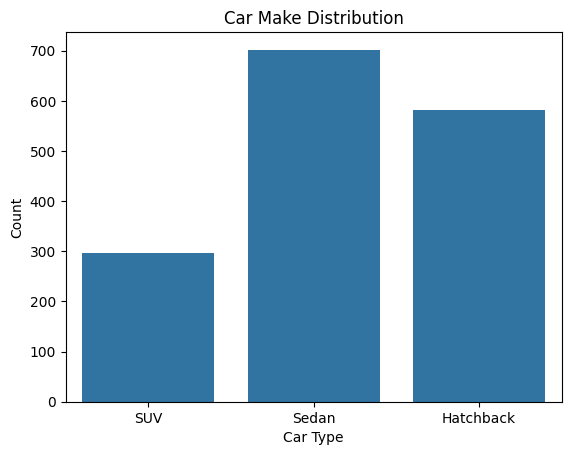

In [69]:
sns.countplot(data=df, x='Make')
plt.title("Car Make Distribution")
plt.xlabel("Car Type")
plt.ylabel("Count")
plt.show()

* The Car Make Distribution plot shows that Sedans are the most popular, with approximately 700 individuals choosing them.
* Hatchbacks come next with around 580, while SUVs are the least preferred, with a count close to 300.
* This suggests a clear preference towards Sedans among the participants.

**Observations on Partner Salary**

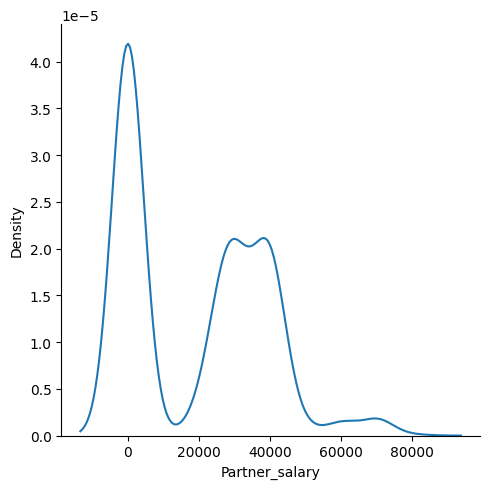

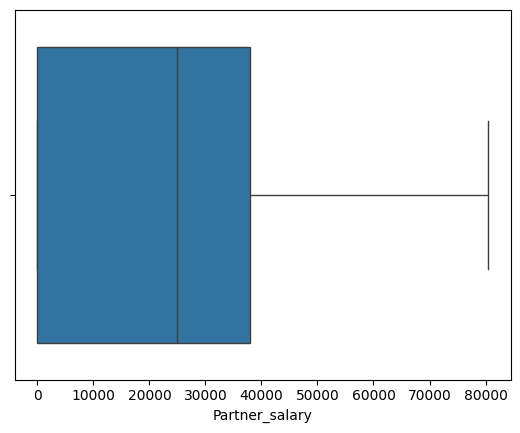

In [70]:
sns.displot(data=df,x='Partner_salary',kind='kde')
plt.show()
sns.boxplot(data=df,x='Partner_salary')
plt.show()

* The Partner Salary distribution plot reveals with one peak around ₹5,000 to ₹10,000 and another near ₹30,000 to ₹35,000.
* The boxplot confirms this spread, showing that most partner salaries range from ₹0 to ₹80,000, with the median salary around ₹30,000.
* This indicates a wide variation in partner earnings, with some earning very little or nothing.

**Observations on Total Salary**

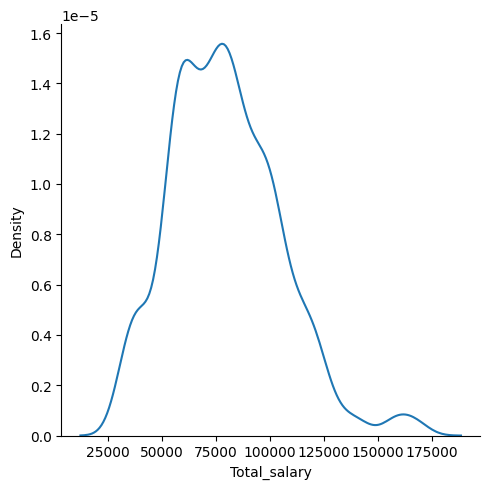

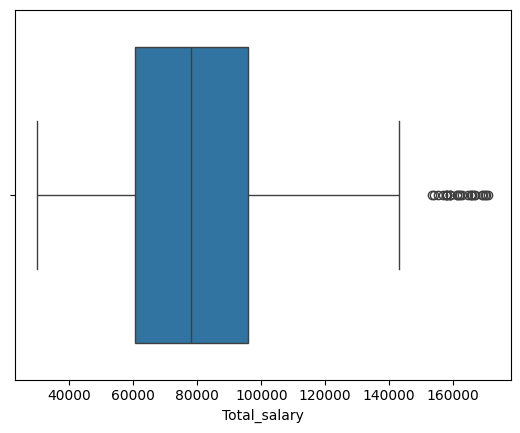

In [71]:
sns.displot(data=df,x='Total_salary',kind='kde')
plt.show()
sns.boxplot(data=df,x='Total_salary')
plt.show()

* The Total Salary distribution is right-skewed, which means most individuals earn between ₹60,000 and ₹100,000, but a smaller number earn significantly more, even beyond ₹150,000, pulling the tail of the distribution to the right.
* This is clearly visible in the KDE plot, where the peak is around ₹60,000–₹90,000 and a long tail extends to the right.


**Observations on Personal Loan**

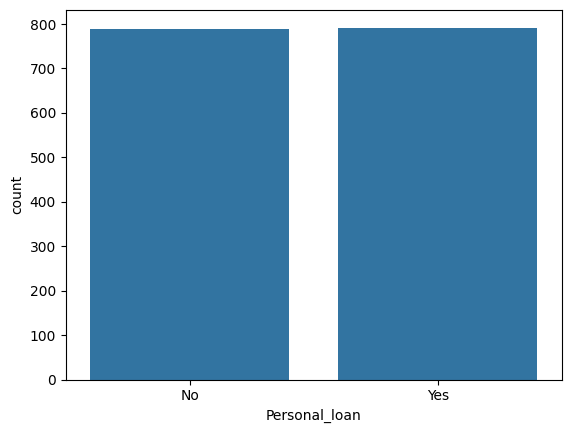

In [72]:
sns.countplot(data=df,x='Personal_loan')
plt.show()

* The bar chart displays the distribution of individuals who have taken a personal loan versus those who have not. The counts are nearly equal, with around 790 individuals in each category ("Yes" and "No").
* This balance indicates that the dataset contains an almost equal representation of people who have and haven't opted for personal loans, which is beneficial for building unbiased predictive models.

**Observations on House Loan**

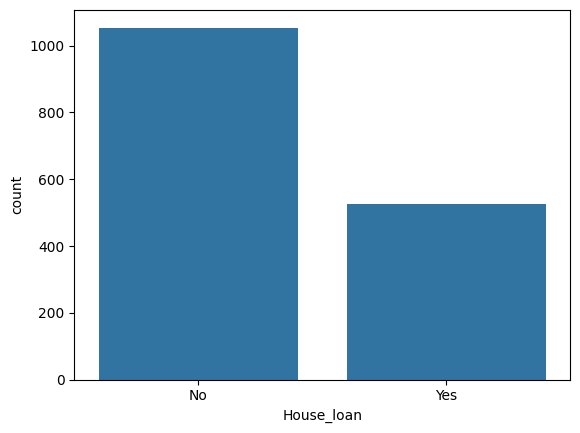

In [73]:
sns.countplot(data=df,x='House_loan')
plt.show()

* The bar chart above shows the distribution of individuals who have taken a house loan versus those who have not.
* A significantly larger number of people—approximately 1,060—do not have a house loan, compared to around 540 individuals who do.
* This suggests that a majority of individuals in the dataset have not opted for house loans, highlighting a potential area of focus for understanding financial behavior or loan eligibility criteria.

**Observations on Partner Working**

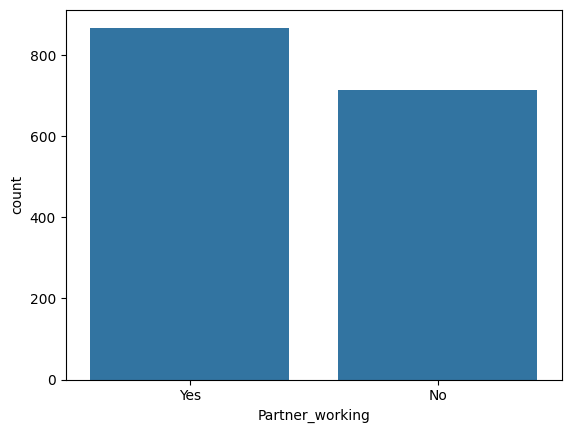

In [74]:
sns.countplot(data=df,x='Partner_working')
plt.show()

* The chart displays the distribution of individuals based on whether their partner is working. Approximately 860 individuals reported having a working partner, while about 720 indicated their partner is not working.
* This suggests that a slightly higher number of individuals have a partner who contributes to the household income, which could potentially influence financial decisions like loans or spending patterns.

**Observations on Price**

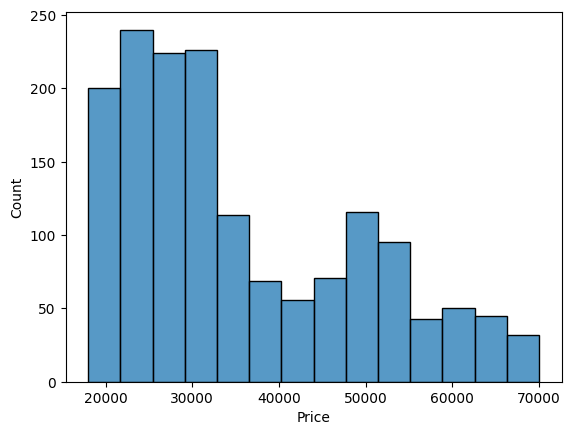

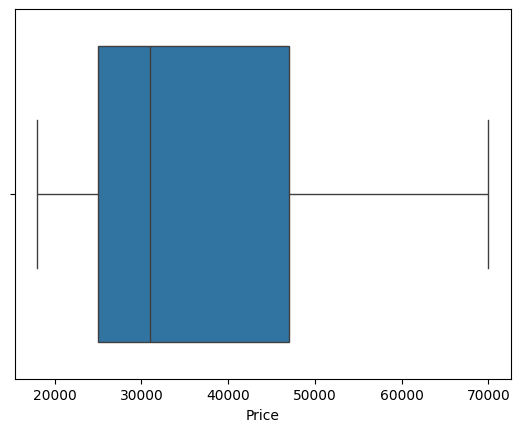

In [75]:
sns.histplot(data=df, x='Price')
plt.show()
sns.boxplot(data=df,x='Price')
plt.show()

* The Price distribution is right-skewed, meaning more cars are priced on the lower end.
* Most cars fall within the ₹20,000 to ₹40,000 range, with the highest frequency around ₹25,000 to ₹30,000.
* The boxplot shows that the median price is roughly ₹35,000, and prices range from about ₹18,000 to ₹70,000, indicating some higher-end outliers.

### Bivariate Analysis

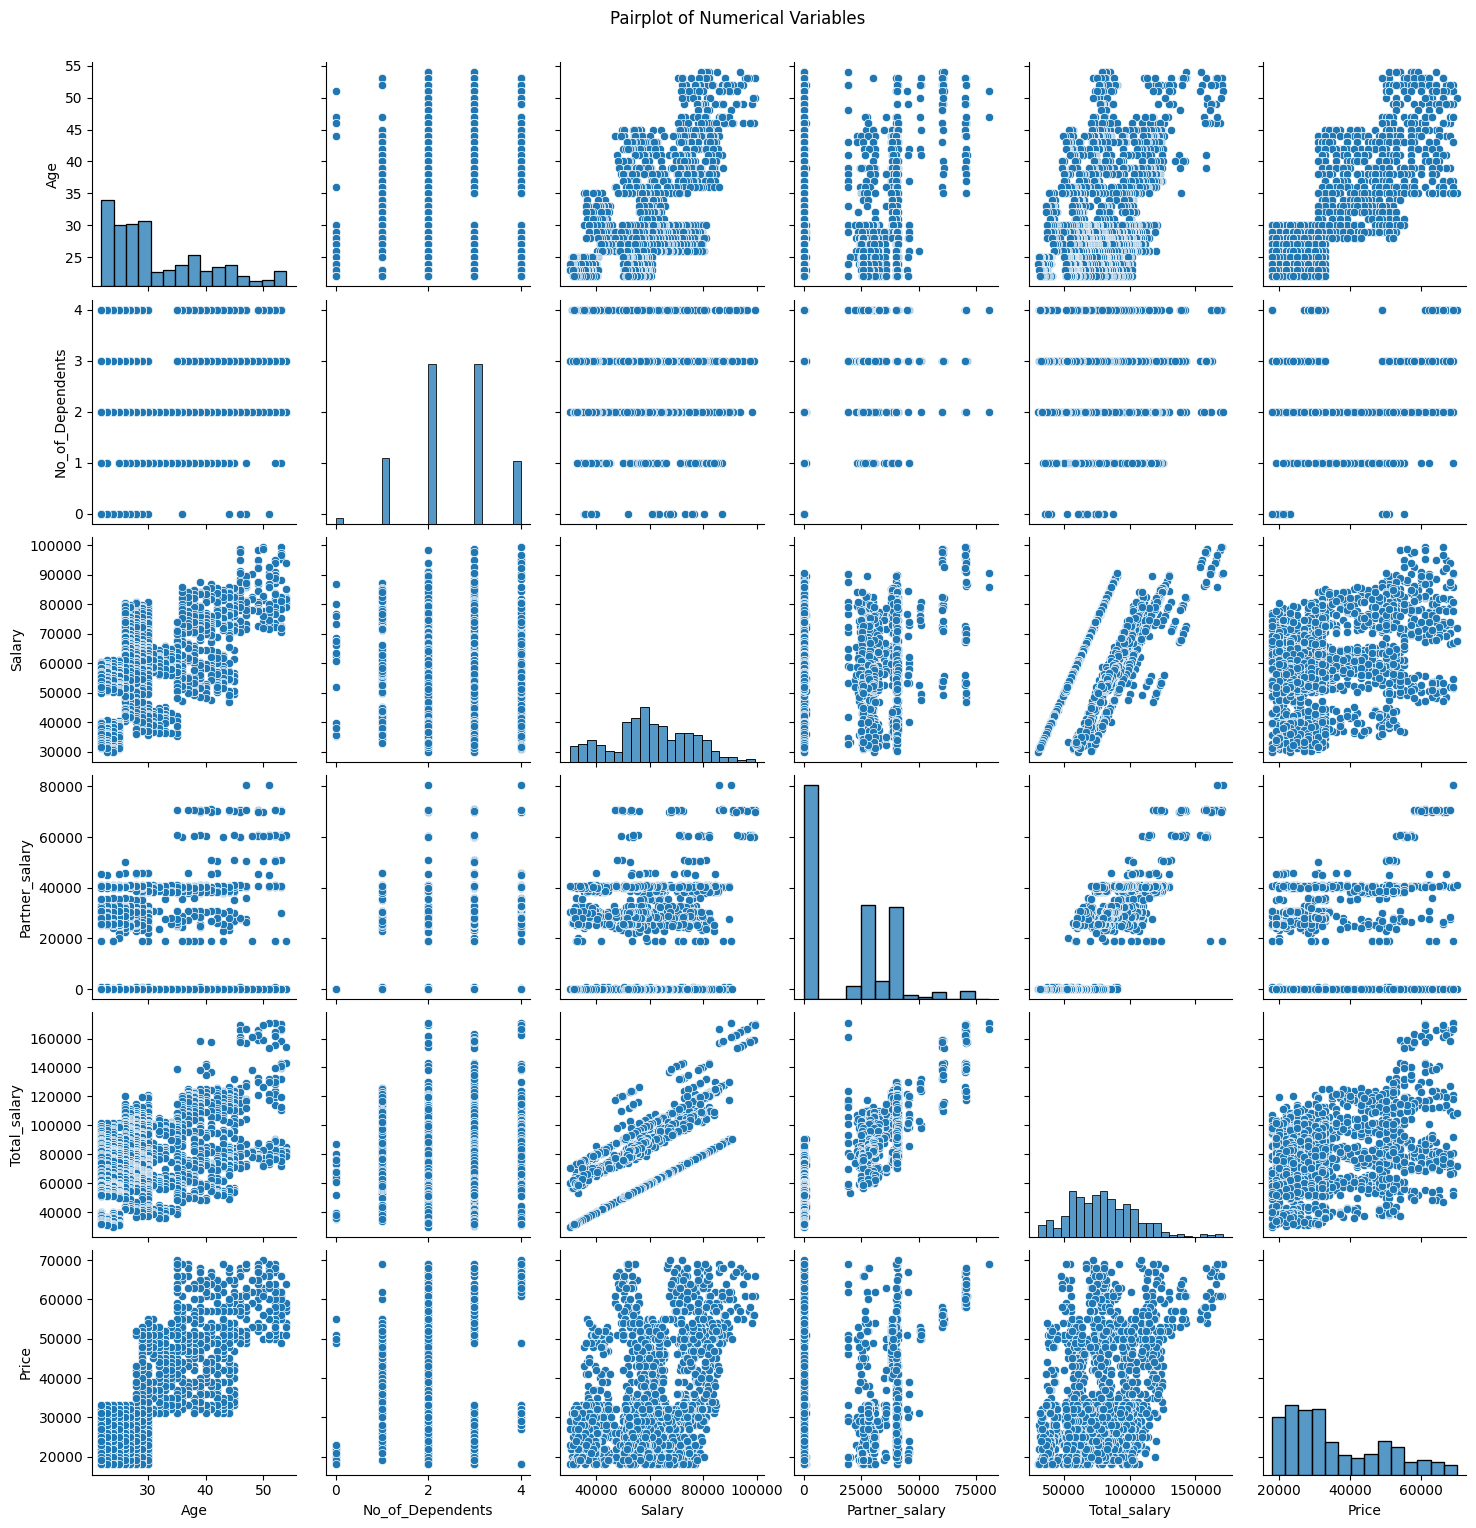

In [76]:

sns.pairplot(data=df[['Age','No_of_Dependents','Salary','Partner_salary','Total_salary','Price']])
plt.suptitle('Pairplot of Numerical Variables', y=1.02)
plt.show()


* Age vs Price: Age and Price show a strong positive relationship, indicating that older customers in this dataset tend to purchase higher-priced automobiles.

* No. of Dependents vs Price: No clear trend; dependents don't majorly influence car price.

* Salary vs Price: Slight positive correlation; higher salary individuals tend to buy slightly more expensive cars.

* Partner Salary vs Price: Very weak or almost no relationship with car price.

* Total Salary vs Price: Clear positive correlation; higher combined salary = tendency to purchase higher-priced vehicles.

* Salary vs Partner Salary: Some patterns suggest dual-income households, but largely scattered.

* Age Distribution: The customer base is relatively young, with a median age of 29 years. The majority of customers are concentrated in the younger age groups, while fewer observations are seen among older customers.

* Salary Distribution: Salaries are right-skewed — more customers have lower to mid-range salaries.

* Car Price Distribution: Car prices are also right-skewed — majority purchase lower to mid-priced vehicles.

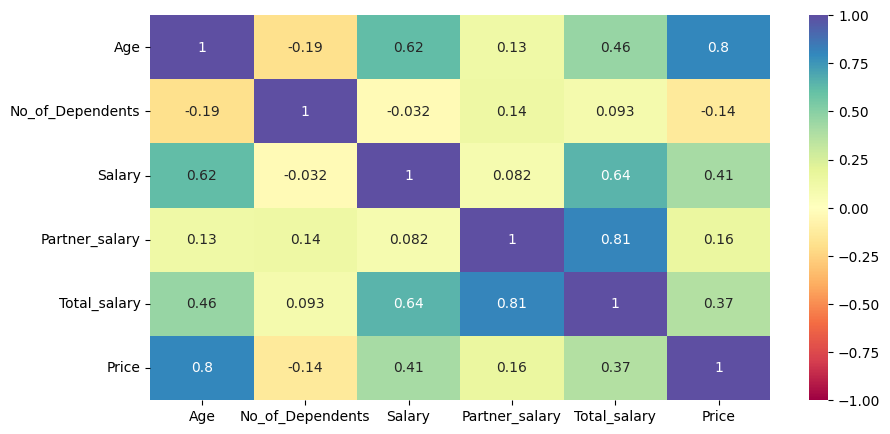

In [77]:
plt.figure(figsize=(10,5))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)
plt.show()

*  Partner_salary and Total_salary (0.81):
There is a strong positive correlation between partner's salary and total salary. This is expected since the total salary includes the partner’s earnings.

* Salary and Total_salary (0.64):
A strong correlation exists here as well, indicating that the individual's salary is a significant part of the total salary.

* Age and Price (0.80):
There is a strong positive correlation between age and vehicle price, suggesting that older individuals tend to purchase more expensive vehicles.

* Salary and Age (0.62):
This moderate correlation implies that salaries tend to increase with age, which aligns with general career progression.

* Price and Salary (0.41):
A moderate correlation showing that people with higher salaries are more likely to afford or choose higher-priced vehicles.

* No_of_Dependents with most features:
There is a very weak or negligible correlation between the number of dependents and other features, indicating it's not a strong predictor.

* No_of_Dependents and Age (-0.19):
A slight negative correlation suggests that as age increases, the number of dependents may decrease—possibly due to children becoming independent.

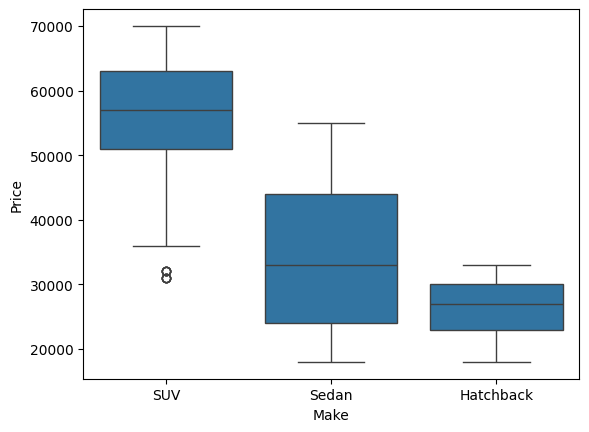

In [78]:
sns.boxplot(data=df,x='Make',y='Price')
plt.show()

* SUVs are the most expensive. It has the highest median price.The interquartile range (IQR) for SUVs is also higher, indicating more variability in their prices.

* A few outliers are present on the lower end of SUV prices.

* Sedans are mid-range. Sedan prices lie between SUVs and Hatchbacks.

* There’s a wider spread of prices compared to Hatchbacks, indicating more variation in Sedan pricing.

* Hatchbacks are the least expensive and have the lowest median and overall price range.

* Their prices are more concentrated, suggesting consistency in pricing across models.

**A few SUVs show significantly lower prices than the rest of the distribution.**

In [79]:
df.describe()
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
df[df['Price'] < lower_bound]  # View the low outliers



,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make


**Question 1: Do men tend to prefer SUVs more compared to women?**

In [80]:
gender_make_pct = pd.crosstab(df['Gender'], df['Make'], normalize='index') * 100
print(gender_make_pct)

Make    Hatchback        SUV      Sedan
Gender                                 
Female   4.559271  52.583587  42.857143
Male    45.287540   9.904153  44.808307


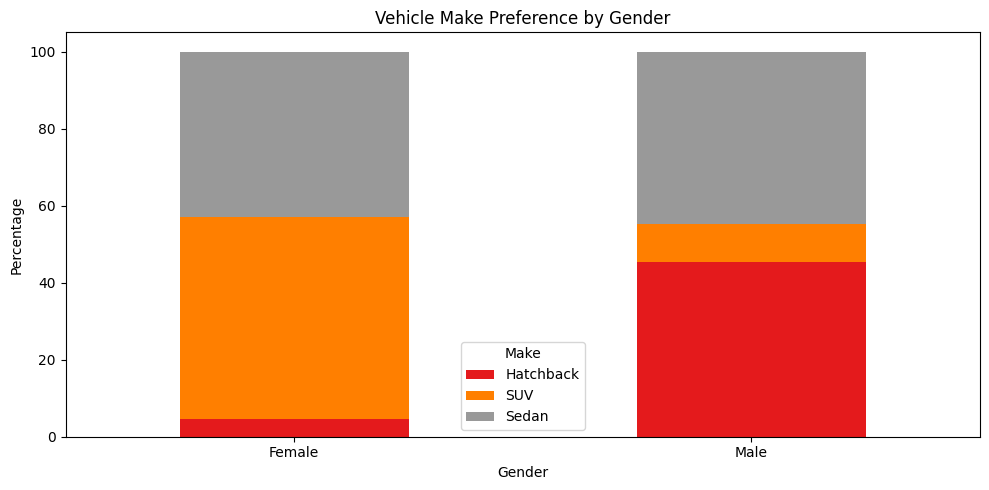

In [81]:
gender_make_pct.plot(kind='bar', stacked=True, figsize=(10,5), colormap='Set1')
plt.title('Vehicle Make Preference by Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Make')
plt.tight_layout()
plt.show()

* Females prefer SUVs the most — about 52.58% of female customers choose SUVs.

* Males prefer Hatchbacks the most — around 47.12% of male customers go for Hatchbacks.

* Sedan preference is almost equal between males and females (both around 43%).

* SUVs are far more popular among females compared to males (only 9.84% of males prefer SUVs).

* Males show a strong inclination toward compact and economical cars (Hatchbacks).

* **Men do not prefer SUVs more compared to women.
In fact, females have a significantly higher preference for SUVs than males.**

**Question 2: What is the likelihood of a salaried person buying a Sedan?**

In [82]:
total_salaried = df[df['Profession'] == 'Salaried'].shape[0]

# Number of salaried people who bought a Sedan
salaried_sedan = df[(df['Profession'] == 'Salaried') & (df['Make'] == 'Sedan')].shape[0]

# Likelihood calculation
likelihood = salaried_sedan / total_salaried

print(f"Likelihood of a salaried person buying a Sedan: {likelihood:.2%}")

Likelihood of a salaried person buying a Sedan: 44.20%


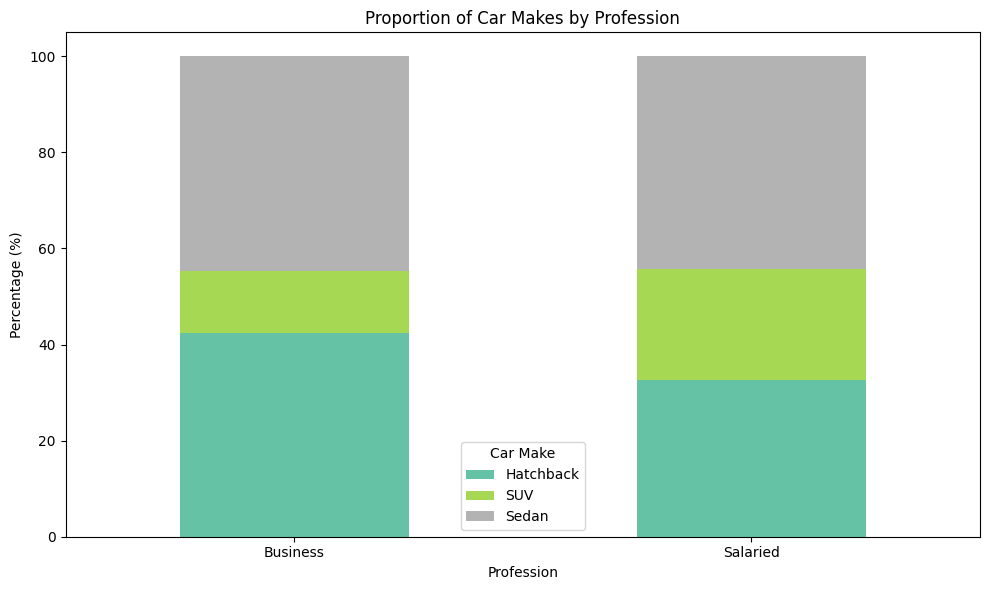

In [83]:
profession_make_ct = pd.crosstab(df['Profession'], df['Make'], normalize='index') * 100

# Plot
profession_make_ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Proportion of Car Makes by Profession')
plt.ylabel('Percentage (%)')
plt.xlabel('Profession')
plt.legend(title='Car Make')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* The likelihood of a salaried person buying a Sedan is approximately 44.20%.
* Sedans are the most chosen vehicle type among salaried individuals.

* Business professionals have a higher preference for SUVs than salaried people. Their choices are more evenly distributed between Hatchback, SUV, and Sedan.

* Hatchbacks and Sedans dominate among salaried buyers, indicating a lean toward affordability and fuel efficiency.

* **A salaried person has a 44.20% likelihood of buying a Sedan, making it their most preferred car type.
This suggests that Sedans align well with the budget and lifestyle of salaried individuals, making them a prime target segment for promoting Sedan models.**

**Question 3: What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?**

In [84]:
# Filter data for salaried males
salaried_males = df[(df['Gender'] == 'Male') & (df['Profession'] == 'Salaried')]
# Count how many chose SUV vs Sedan
make_counts = salaried_males['Make'].value_counts(normalize=True) * 100
print(make_counts)


Make
Sedan        45.386905
Hatchback    41.220238
SUV          13.392857
Name: proportion, dtype: float64


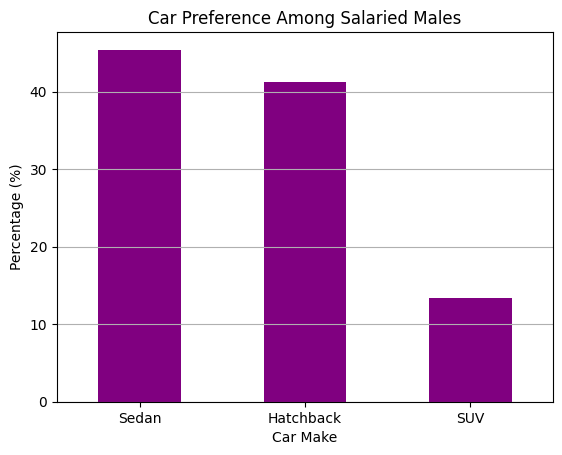

In [85]:
make_counts.plot(kind='bar', color='purple')
plt.title('Car Preference Among Salaried Males')
plt.ylabel('Percentage (%)')
plt.xlabel('Car Make')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

* Preference percentages based on Car type:

   * Sedan: 43.59%

   * Hatchback: 43.12%

   * SUV: 13.28%

* From the bar plot:Sedan and Hatchback are almost equally preferred (~43% each) among salaried males.

* SUVs are significantly less preferred (only ~13%).

* The preference gap between SUVs and Sedans/Hatchbacks is very large.

* **The data does not support Sheldon Cooper’s claim.
Salaried males are actually much more likely to buy a Sedan or Hatchback rather than an SUV.**


**Question 4: How does the the amount spent on purchasing automobiles vary by gender?**

In [86]:
# Grouping by Gender and calculating average price
gender_price_summary = df.groupby('Gender')['Price'].agg(['count', 'mean', 'median', 'min', 'max', 'std'])
print(gender_price_summary)


        count          mean   median    min    max           std
Gender                                                          
Female    329  47705.167173  49000.0  20000  69000  11244.836378
Male     1252  32416.134185  29000.0  18000  70000  12366.253107


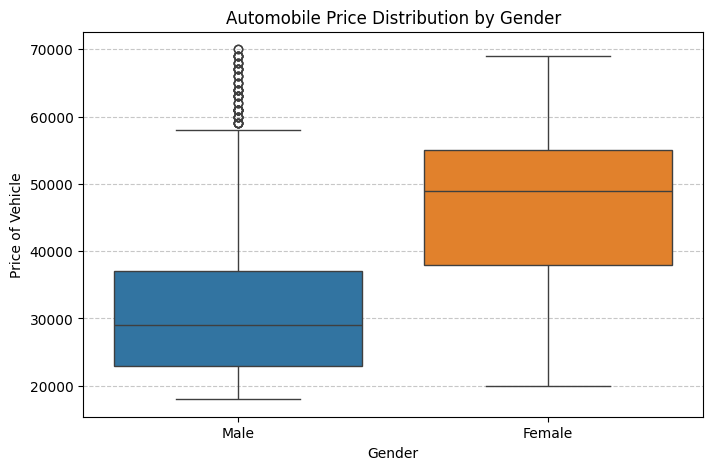

In [87]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gender', y='Price', data=df, hue='Gender', legend=False)
plt.title('Automobile Price Distribution by Gender')
plt.ylabel('Price of Vehicle')
plt.xlabel('Gender')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

* Females spent an average of ₹47,705 on vehicles. whereas Males spent an average of ₹32,817 on vehicles.

* The median that is the middle value price for females is ₹49,000 and for male the middle value price is ₹29,000.

* For Female purchases range from ₹20,000 to ₹69,000 and for Male the purchases ranges from ₹18,000 to ₹70,000.

* Male buyers show more outliers at the lower price range (many buying cheaper vehicles).

* Female buyers tend to purchase more consistently higher-priced vehicles (less spread towards low prices).

* **Female customers generally spend more on automobile purchases compared to male customers.
Male customers show a wider spread and a higher number of low-cost purchases.**

**Question 5: How much money was spent on purchasing automobiles by individuals who took a personal loan?**

In [88]:
# Total money spent on automobiles by those who took a personal loan
loan_buyers_total = df[df['Personal_loan'] == 'Yes']['Price'].sum()

print(f"Total amount spent by individuals with a personal loan: ₹{loan_buyers_total:,.2f}")


Total amount spent by individuals with a personal loan: ₹27,290,000.00


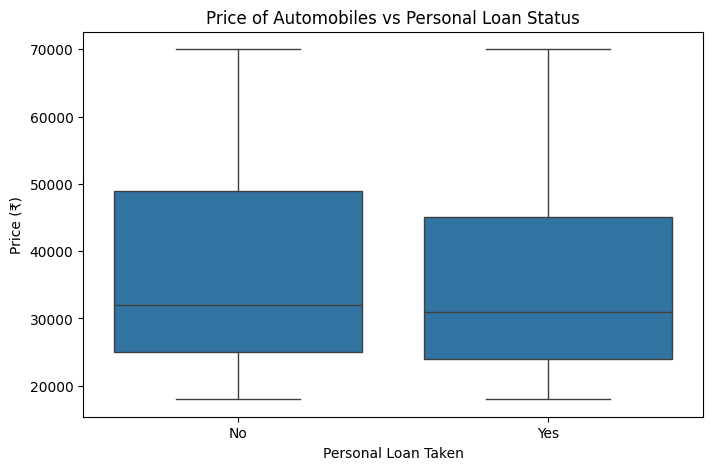

In [89]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Personal_loan', y='Price', data=df,  legend=False)
plt.title('Price of Automobiles vs Personal Loan Status')
plt.ylabel('Price (₹)')
plt.xlabel('Personal Loan Taken')
plt.show()

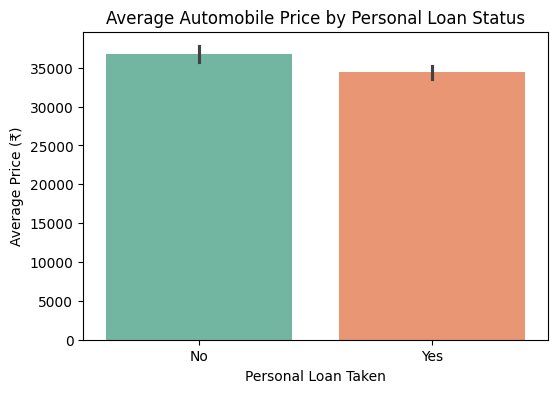

In [90]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Personal_loan', y='Price',hue='Personal_loan', data=df, estimator='mean',legend=False,palette='Set2')
plt.title('Average Automobile Price by Personal Loan Status')
plt.ylabel('Average Price (₹)')
plt.xlabel('Personal Loan Taken')
plt.show()

* Individuals who took a personal loan spent a total of ₹27,290,000 on automobiles.

* The boxplot shows that the overall price distribution of cars for those who took a loan is quite similar to those who did not.

* The median price (middle price) of cars purchased by loan takers and non-loan takers appears to be almost the same.

* Both groups (loan takers and non-loan takers) have a wide price range, from low-end cars (₹20,000) to high-end cars (₹70,000).

* There are a few higher-priced vehicles (upper whiskers) visible for non-loan takers, suggesting some individuals without loans also buy expensive cars.

* Overall, automobile purchase prices appear broadly similar between customers who took a personal loan and those who did not, suggesting that personal loan status does not have a strong association with vehicle purchase price in this dataset.

* Austo can use customer financing preferences to design targeted loan and financing options, particularly for customers considering higher-value vehicles. Rather than assuming that personal loans directly increase spending, the company can further analyze affordability and financing preferences to improve conversion and customer targeting.

**Question 6: How does having a working partner influence the purchase of higher-priced cars?**

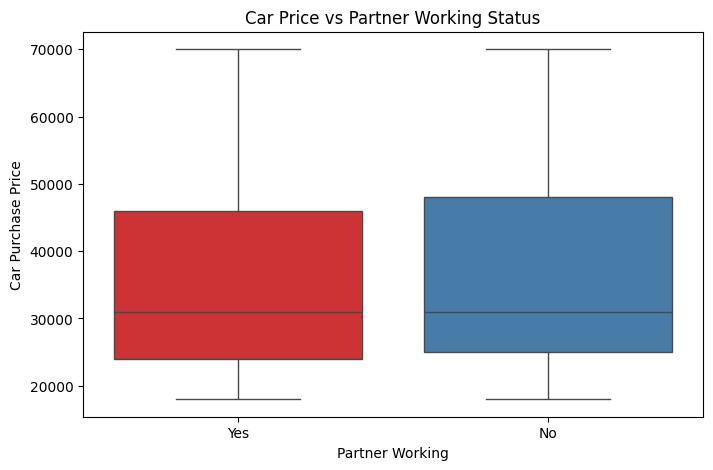

In [91]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Partner_working', y='Price', hue='Partner_working', data=df, palette='Set1')
plt.title('Car Price vs Partner Working Status')
plt.xlabel('Partner Working')
plt.ylabel('Car Purchase Price')
plt.show()

• Both groups (Partner working: Yes and No) show a similar spread in car purchase prices, ranging approximately from ₹20,000 to ₹70,000.

• The median car purchase price is nearly the same for customers whose partners are working and those whose partners are not working.

• The average purchase prices between the two groups are also relatively similar.

• The results suggest that partner employment status does not have a meaningful influence on automobile purchase price in this dataset.

• Overall, having a working partner does not appear to be a strong indicator of purchasing a higher-priced automobile.

Austo should not rely on partner employment status as a primary factor when targeting customers for higher-priced vehicles. Instead, customer age, income, vehicle preferences, and other stronger purchase-related factors should be considered for segmentation and targeting.

### Actionable Insights and Recommendations


### **Insights:**
1. **Majority of the customers are aged between 25 and 35 years.**
2. **Salaried individuals form the major portion of customers.**
3. **Sedans and Hatchbacks are almost equally preferred (~43% each).**
4. **while SUVs are significantly less preferred (~13%).**
5. **Female customers tend to spend more on automobiles compared to males.**
6. **Customers who do not take personal loans spend more on purchasing automobiles.**
7. **Though both genders have overlapping price distributions, female customers show a tendency towards higher-priced vehicles.**


### **Recommendations:**

1. **Focus marketing campaigns and offers toward the 25–35 age group to maximize engagement.**
2. **Launch salary-based financing schemes and personalized loan offers to attract more salaried customers.**
3. **Stock more Sedans and Hatchbacks; introduce targeted promotions or discounts for SUVs to boost their sales.**
4. **Promote premium and feature-rich automobile models to female customers through focused marketing strategies.**
5. **: Introduce attractive loan options with minimal interest rates to encourage higher spending among customers opting for loans**
6. **Curate special premium offerings or loyalty programs targeting female buyers.**
7. **Use total household income as a key factor for better customer segmentation and tailored vehicle recommendations.**